In [7]:
from pathlib import Path
import os
import random
import time
import csv
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# python-louvain 包：用于把网络节点划分成社区，后面 M3/M4/M6/M7 都依赖这个社区划分结果。
try:
    import community as community_louvain
except ImportError:
    raise ImportError(
        "没有找到 python-louvain。请在 Terminal 里运行：pip install python-louvain"
    )


# =========================
# 基本参数
# =========================

SEED = 42
random.seed(SEED)

# 最大删边比例：1.0 表示最多把原图的所有边都尝试删除一遍；如果网络很大，可先改成 0.6 加快测试。
MAX_REMOVE_FRAC = 1.0

# 当前项目目录：默认从 notebook 启动位置开始找，下面几行会尽量自动定位到 network collapse 项目根目录。
BASE_DIR = Path.cwd()

# 如果当前目录在 data/result/real_networks/sbm 这些子目录里，就自动往上找项目根目录。
while BASE_DIR.name.lower() in ["data", "result", "real_networks", "sbm"] and BASE_DIR.parent != BASE_DIR:
    BASE_DIR = BASE_DIR.parent

# 如果从 C:\Users\86185 这样的上级目录启动，就自动进入 network collapse，避免相对路径读错。
if (BASE_DIR / "network collapse").exists():
    BASE_DIR = BASE_DIR / "network collapse"

os.chdir(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
REAL_DIR = DATA_DIR / "real_networks"
RESULT_DIR = BASE_DIR / "result"

DATA_DIR.mkdir(exist_ok=True)
REAL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)


# =========================
# 所有真实网络
# 注意：这里都指向数据集文件夹，不直接写死具体文件名。
# 这样每个数据集下面只要有 .gml 或 .mtx，读取函数就能自动找到真实图文件。
# =========================

DATASETS = {
    "karate": REAL_DIR / "karate",
    "football": REAL_DIR / "football",
    "ca_netscience": REAL_DIR / "ca-netscience",
    "bio_diseasome": REAL_DIR / "bio-diseasome",
    "inf_USAir97": REAL_DIR / "inf-USAir97",
}


print("项目目录：", BASE_DIR)
print("数据目录：", DATA_DIR)
print("真实网络目录：", REAL_DIR)
print("结果目录：", RESULT_DIR)
print("NetworkX 版本：", nx.__version__)
print("最大删除比例 MAX_REMOVE_FRAC =", MAX_REMOVE_FRAC)

print("\n待处理网络：")
for name, path in DATASETS.items():
    print(name, "->", path, "存在不：", path.exists())

项目目录： C:\Users\86185\network collapse
数据目录： C:\Users\86185\network collapse\data
真实网络目录： C:\Users\86185\network collapse\data\real_networks
结果目录： C:\Users\86185\network collapse\result
NetworkX 版本： 2.6.3
最大删除比例 MAX_REMOVE_FRAC = 1.0

待处理网络：
karate -> C:\Users\86185\network collapse\data\real_networks\karate 存在不： True
football -> C:\Users\86185\network collapse\data\real_networks\football 存在不： True
ca_netscience -> C:\Users\86185\network collapse\data\real_networks\ca-netscience 存在不： True
bio_diseasome -> C:\Users\86185\network collapse\data\real_networks\bio-diseasome 存在不： True
inf_USAir97 -> C:\Users\86185\network collapse\data\real_networks\inf-USAir97 存在不： True


In [2]:
# =========================
# 第 2 块：读取网络 + 七种攻击的选边函数
# 支持：
# 1. .gml：karate、football
# 2. .mtx：ca-netscience、bio-diseasome、inf-USAir97
# =========================

def find_first_graph_file(folder):
    """
    在一个网络文件夹里自动寻找可读取的图文件。
    支持：
    - .gml：karate、football
    - .mtx：ca-netscience、bio-diseasome、inf-USAir97
    - .edges/.txt：备用
    """
    folder = Path(folder)

    candidates = []

    # 优先级：gml > mtx > edges/txt。优先读结构信息更明确的格式，找不到再用通用边列表格式。
    for suffix in ["*.gml", "*.mtx", "*.edges", "*.txt"]:
        candidates.extend(folder.rglob(suffix))

    # 排除说明文件或标签文件，只保留真正描述网络边关系的数据文件。
    candidates = [
        p for p in candidates
        if "readme" not in p.name.lower()
        and "label" not in p.name.lower()
        and "group" not in p.name.lower()
    ]

    candidates = sorted(candidates, key=lambda p: str(p).lower())

    if not candidates:
        raise FileNotFoundError(
            f"在 {folder} 下面没有找到 .gml/.mtx/.edges/.txt 文件"
        )

    return candidates[0]


def read_edge_list_like_file(path):
    """
    备用读取方式：
    如果 .mtx 文件不是标准 Matrix Market 格式，
    就把它当作边列表读取。
    只取每行前两个数字作为一条边。
    """
    G = nx.Graph()

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    numeric_lines = []

    for line in lines:
        line = line.strip()

        if not line:
            continue

        if line.startswith("#") or line.startswith("%"):
            continue

        parts = line.replace(",", " ").split()

        nums = []

        for x in parts:
            try:
                nums.append(int(float(x)))
            except Exception:
                pass

        if len(nums) >= 2:
            numeric_lines.append(nums)

    if not numeric_lines:
        raise ValueError(f"{path} 里面没有读到可用边列表")

    # 有些非标准 mtx 第一行可能是：节点数 节点数 边数。
    # 这种第一行是矩阵规模说明，不代表真实边，所以读取边列表前要跳过。
    first = numeric_lines[0]

    if len(first) >= 3:
        a, b, c = first[0], first[1], first[2]

        # 例如 379 379 914，通常表示 379 个节点、914 条边，不是节点 379 和 379 之间的一条边。
        if a == b and c >= len(numeric_lines) - 5:
            numeric_lines = numeric_lines[1:]

    for nums in numeric_lines:
        u, v = nums[0], nums[1]

        if u != v:
            G.add_edge(u, v)

    return G


def load_simple_graph(path):
    """
    读取真实网络，并统一处理成：
    无向图、无权图、简单图、无自环、只取最大连通分量。
    """
    path = Path(path)

    # 关键：如果传进来的是文件夹，先自动找里面真正的图文件，保持 DATASETS 配置简洁。
    if path.is_dir():
        path = find_first_graph_file(path)

    if not path.exists():
        raise FileNotFoundError(f"找不到文件：{path}")

    suffix = path.suffix.lower()

    print("实际读取文件：", path)

    if suffix == ".gml":
        # karate 和 football 用这个分支读取。
        # label=None 表示直接使用节点 id，避免某些 gml 文件缺少 label 属性时报错。
        G_raw = nx.read_gml(path, label=None)

    elif suffix == ".mtx":
        from scipy.io import mmread
        from scipy import sparse

        try:
            # 标准 Matrix Market 格式走这里：先读成矩阵，再转成 NetworkX 无向图。
            A = mmread(str(path))

            if sparse.issparse(A):
                A = A.tocsr()
            else:
                A = sparse.csr_matrix(A)

            try:
                A.eliminate_zeros()
            except Exception:
                pass

            # NetworkX 新版本推荐 from_scipy_sparse_array，老版本用 from_scipy_sparse_matrix。
            # 这里做版本兼容，保证在不同 NetworkX 环境下都能运行。
            if hasattr(nx, "from_scipy_sparse_array"):
                G_raw = nx.from_scipy_sparse_array(
                    A,
                    create_using=nx.Graph()
                )
            else:
                G_raw = nx.from_scipy_sparse_matrix(
                    A,
                    create_using=nx.Graph()
                )

        except Exception as e:
            # 如果不是标准 Matrix Market，就当边列表读，适配一些下载下来的非标准 .mtx 数据。
            print("标准 Matrix Market 读取失败，改用边列表方式读取。")
            print("原始错误：", repr(e))

            G_raw = read_edge_list_like_file(path)

    elif suffix in [".edges", ".txt"]:
        G_raw = nx.read_edgelist(
            path,
            comments="#",
            nodetype=str,
            data=False
        )

    else:
        raise ValueError(f"暂不支持这个文件格式：{path}")

    # 统一转成简单无向无权图：去掉方向、权重和重复边，保证不同数据集进入同一套攻击流程。
    G = nx.Graph()
    G.add_nodes_from(G_raw.nodes())
    G.add_edges_from(G_raw.edges())
    G.remove_edges_from(nx.selfloop_edges(G))

    # 只取最大连通分量：后续 GCC 比例以初始最大连通子图为基准，避免孤立小分量干扰坍塌曲线。
    if G.number_of_nodes() > 0 and not nx.is_connected(G):
        gcc_nodes = max(nx.connected_components(G), key=len)
        G = G.subgraph(gcc_nodes).copy()

    print("节点数：", G.number_of_nodes())
    print("边数：", G.number_of_edges())
    print("是否连通：", nx.is_connected(G))
    print("-" * 60)

    return G


def largest_cc_subgraph(G):
    """
    返回当前图的最大连通分量诱导子图。
    """
    if G.number_of_nodes() == 0:
        return G.copy()

    if nx.is_connected(G):
        return G.copy()

    gcc_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(gcc_nodes).copy()


def gcc_ratio(G, original_n):
    """
    当前最大连通分量节点数 / 原始节点数。
    """
    if original_n == 0 or G.number_of_nodes() == 0:
        return 0

    H = largest_cc_subgraph(G)
    return H.number_of_nodes() / original_n


def edge_sort_key(edge):
    """
    给边一个稳定排序键，避免并列时随机。
    """
    u, v = edge
    a, b = sorted([str(u), str(v)])
    return (a, b)


def louvain_communities(G, seed=SEED):
    """
    用 python-louvain 做社区检测。
    返回：list[set(nodes)]
    """
    if G.number_of_nodes() == 0:
        return []

    partition = community_louvain.best_partition(
        G,
        random_state=seed
    )

    comm_dict = defaultdict(set)
    for node, cid in partition.items():
        comm_dict[cid].add(node)

    communities = list(comm_dict.values())
    communities = sorted(
        communities,
        key=lambda c: (-len(c), sorted(map(str, c))[0])
    )

    return communities


def choose_degree_product_edge(G):
    """
    M2：删除当前 GCC 中 k_i * k_j 最大的边。
    """
    H = largest_cc_subgraph(G)

    if H.number_of_edges() == 0:
        return None

    deg = dict(H.degree())

    candidates = []
    for u, v in H.edges():
        score = deg[u] * deg[v]
        candidates.append((score, edge_sort_key((u, v)), (u, v)))

    return max(candidates, key=lambda x: (x[0], x[1]))[2]


def choose_betweenness_edge(G):
    """
    M5：删除当前 GCC 中 edge betweenness 最大的边。
    每删一条边后重新计算一次。
    """
    H = largest_cc_subgraph(G)

    if H.number_of_edges() == 0:
        return None

    bc = nx.edge_betweenness_centrality(
        H,
        normalized=True,
        weight=None
    )

    candidates = []
    for edge, score in bc.items():
        candidates.append((score, edge_sort_key(edge), edge))

    return max(candidates, key=lambda x: (x[0], x[1]))[2]


def choose_community_edge(G, mode, seed=SEED):
    """
    基于 Louvain 社区结构的跨社区边攻击。
    每删一条边后，只在当前 GCC 上重新做 Louvain 社区检测。

    支持四种 mode：

    1. community_size
       M3: max C_i * C_j

    2. community_internal_div_inter
       M4: max E_i * E_j / E_ij

    3. community_internal_product
       M6: max E_i * E_j

    4. community_size_div_inter
       M7: max C_i * C_j / E_ij

    5. community_bridge_degree
       M8: max (C_i * C_j / E_ij) * (k_u * k_v)
    """
    H = largest_cc_subgraph(G)

    if H.number_of_edges() == 0:
        return None

    communities = louvain_communities(H, seed=seed)

    # 如果 Louvain 只划出一个社区，说明当前图没有可比较的跨社区边，就退化为度乘积攻击。
    if len(communities) < 2:
        return choose_degree_product_edge(G)

    node_to_comm = {}
    comm_sizes = []

    for cid, comm in enumerate(communities):
        comm_sizes.append(len(comm))
        for node in comm:
            node_to_comm[node] = cid

    # internal_edges[i] = 社区 i 内部边数 E_i，用来衡量该社区内部连接强度。
    internal_edges = [0] * len(communities)

    # inter_counts[(i, j)] = 社区 i 和社区 j 之间边数 E_ij，用来衡量两个社区之间连接是否稀疏。
    inter_counts = defaultdict(int)

    for u, v in H.edges():
        cu = node_to_comm[u]
        cv = node_to_comm[v]

        if cu == cv:
            internal_edges[cu] += 1
        else:
            a, b = sorted((cu, cv))
            inter_counts[(a, b)] += 1

    deg = dict(H.degree())
    candidates = []

    for u, v in H.edges():
        cu = node_to_comm[u]
        cv = node_to_comm[v]

        # 社区攻击只考虑跨社区边，因为目标是优先切断社区之间的桥接关系。
        if cu == cv:
            continue

        a, b = sorted((cu, cv))
        eij = inter_counts[(a, b)]

        ci = comm_sizes[cu]
        cj = comm_sizes[cv]

        ei = internal_edges[cu]
        ej = internal_edges[cv]

        if mode == "community_size":
            # M3: C_i * C_j，优先删除连接两个大社区的跨社区边。
            score = ci * cj

        elif mode == "community_internal_div_inter":
            # M4: E_i * E_j / E_ij，优先删除连接两个内部很密、彼此连接很少的社区的边。
            score = (ei * ej) / eij if eij != 0 else 0

        elif mode == "community_internal_product":
            # M6: E_i * E_j，只看两个社区内部边数乘积，强调社区内部连接规模。
            score = ei * ej

        elif mode == "community_size_div_inter":
            # M7: C_i * C_j / E_ij，优先删除大社区之间较稀缺的跨社区边。
            score = (ci * cj) / eij if eij != 0 else 0

        elif mode == "community_bridge_degree":
            # M8: (C_i * C_j / E_ij) * (k_u * k_v)。
            # 前半部分衡量两个社区之间的桥接稀缺性，后半部分强调这条边两端节点的局部连接能力。
            community_bridge_score = (ci * cj) / eij if eij != 0 else 0
            score = community_bridge_score * deg[u] * deg[v]

        else:
            raise ValueError(f"未知 mode: {mode}")

        # 并列时用度乘积辅助排序，让同分候选边的选择稳定且更偏向高连接节点。
        tie_score = deg[u] * deg[v]

        candidates.append(
            (score, tie_score, edge_sort_key((u, v)), (u, v))
        )

    # 如果没有跨社区边，也退化为度乘积攻击，保证每一步仍能选出可删除边。
    if not candidates:
        return choose_degree_product_edge(G)

    return max(candidates, key=lambda x: (x[0], x[1], x[2]))[3]


print("第 2 块加载完成：读取函数和选边函数已准备好。")

第 2 块加载完成：读取函数和选边函数已准备好。


In [3]:
METHODS = [
    ("M1 Random", "random"),
    ("M2 max k_i*k_j", "degree_product"),
    ("M3 max C_i*C_j with Louvain", "community_size"),
    ("M4 max E_i*E_j/E_ij with Louvain", "community_internal_div_inter"),
    ("M5 max edge betweenness", "edge_betweenness"),
    ("M6 max E_i*E_j with Louvain", "community_internal_product"),
    ("M7 max C_i*C_j/E_ij with Louvain", "community_size_div_inter"),
    ("M8 max (C_i*C_j/E_ij)*(k_i*k_j) with Louvain", "community_bridge_degree"),
]


def simulate_attack(G0, method_key, method_label, seed=SEED, max_remove_frac=MAX_REMOVE_FRAC):
    """
    对一个网络执行某一种攻击，返回每一步的 GCC 比例。
    """
    rng = random.Random(seed)
    G = G0.copy()

    original_n = G.number_of_nodes()
    original_m = G.number_of_edges()

    if original_m == 0:
        return [{
            "method": method_label,
            "removed_edges": 0,
            "remove_ratio": 0,
            "gcc_ratio": 0,
        }]

    max_steps = int(original_m * max_remove_frac)

    records = []

    # 第 0 步：还没有删边，用它作为每条攻击曲线的起点，通常 GCC 比例为 1。
    records.append({
        "method": method_label,
        "removed_edges": 0,
        "remove_ratio": 0,
        "gcc_ratio": gcc_ratio(G, original_n),
    })

    # M1 随机攻击：提前打乱所有边，后续每一步从随机序列里取当前仍存在的边删除。
    random_edges = list(G.edges())
    rng.shuffle(random_edges)

    removed_count = 0

    for _ in range(max_steps):
        if G.number_of_edges() == 0:
            break

        if method_key == "random":
            edge_to_remove = None

            while random_edges:
                e = random_edges.pop()
                if G.has_edge(*e):
                    edge_to_remove = e
                    break

        elif method_key == "degree_product":
            edge_to_remove = choose_degree_product_edge(G)

        elif method_key == "community_size":
            edge_to_remove = choose_community_edge(
                G,
                mode="community_size",
                seed=seed
            )

        elif method_key == "community_internal_div_inter":
            edge_to_remove = choose_community_edge(
                G,
                mode="community_internal_div_inter",
                seed=seed
            )

        elif method_key == "edge_betweenness":
            edge_to_remove = choose_betweenness_edge(G)

        elif method_key == "community_internal_product":
            edge_to_remove = choose_community_edge(
                G,
                mode="community_internal_product",
                seed=seed
            )

        elif method_key == "community_size_div_inter":
            edge_to_remove = choose_community_edge(
                G,
                mode="community_size_div_inter",
                seed=seed
            )

        elif method_key == "community_bridge_degree":
            edge_to_remove = choose_community_edge(
                G,
                mode="community_bridge_degree",
                seed=seed
            )

        else:
            raise ValueError(f"未知攻击模式: {method_key}")

        if edge_to_remove is None:
            break

        if G.has_edge(*edge_to_remove):
            G.remove_edge(*edge_to_remove)
            removed_count += 1

        records.append({
            "method": method_label,
            "removed_edges": removed_count,
            "remove_ratio": removed_count / original_m,
            "gcc_ratio": gcc_ratio(G, original_n),
        })

    return records


def save_records_to_csv(records, csv_path):
    """
    保存攻击过程数据。
    """
    fieldnames = [
        "method",
        "removed_edges",
        "remove_ratio",
        "gcc_ratio",
    ]

    with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(records)


def plot_attack_results(records, title, fig_path):
    """
    画七种攻击模式的 GCC 折线图。
    """
    plt.figure(figsize=(8, 5))

    for method_label, _ in METHODS:
        xs = [
            r["remove_ratio"]
            for r in records
            if r["method"] == method_label
        ]
        ys = [
            r["gcc_ratio"]
            for r in records
            if r["method"] == method_label
        ]

        if len(xs) == 0:
            continue

        plt.plot(
            xs,
            ys,
            linewidth=1.6,
            label=method_label
        )

    plt.xlabel("Removed edge ratio", fontsize=10)
    plt.ylabel("Relative size of GCC", fontsize=10)
    plt.title(title, fontsize=11)

    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)

    plt.legend(fontsize=7)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(fig_path, dpi=250, bbox_inches="tight")
    plt.show()

    print("图已保存：", fig_path)


print("第 3 块加载完成：七种攻击仿真函数已准备好。")

第 3 块加载完成：七种攻击仿真函数已准备好。


开始处理网络：karate
路径： C:\Users\86185\network collapse\data\real_networks\karate
实际读取文件： C:\Users\86185\network collapse\data\real_networks\karate\karate.gml
节点数： 34
边数： 78
是否连通： True
------------------------------------------------------------
网络： karate
节点数： 34
边数： 78
初始 GCC 比例： 1.0
最大删除比例： 1.0
------------------------------------------------------------
正在运行：karate - M1 Random
完成：karate - M1 Random，用时 0.02 秒
------------------------------------------------------------
正在运行：karate - M2 max k_i*k_j
完成：karate - M2 max k_i*k_j，用时 0.03 秒
------------------------------------------------------------
正在运行：karate - M3 max C_i*C_j with Louvain
完成：karate - M3 max C_i*C_j with Louvain，用时 0.09 秒
------------------------------------------------------------
正在运行：karate - M4 max E_i*E_j/E_ij with Louvain
完成：karate - M4 max E_i*E_j/E_ij with Louvain，用时 0.08 秒
------------------------------------------------------------
正在运行：karate - M5 max edge betweenness
完成：karate - M5 max edge betweenness，用时 0.08 秒
--

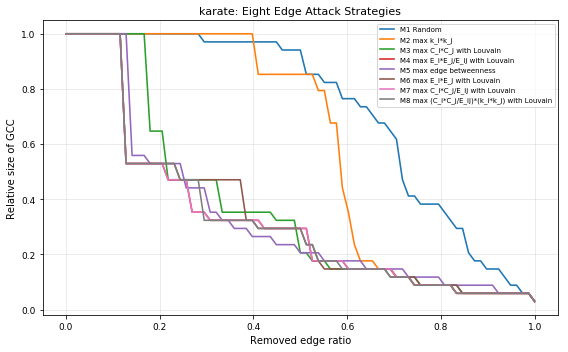

图已保存： C:\Users\86185\network collapse\result\karate\karate_seven_attacks.png
数据已保存： C:\Users\86185\network collapse\result\karate\karate_seven_attacks.csv
图片已保存： C:\Users\86185\network collapse\result\karate\karate_seven_attacks.png
开始处理网络：football
路径： C:\Users\86185\network collapse\data\real_networks\football
实际读取文件： C:\Users\86185\network collapse\data\real_networks\football\football.gml
节点数： 115
边数： 613
是否连通： True
------------------------------------------------------------
网络： football
节点数： 115
边数： 613
初始 GCC 比例： 1.0
最大删除比例： 1.0
------------------------------------------------------------
正在运行：football - M1 Random
完成：football - M1 Random，用时 0.58 秒
------------------------------------------------------------
正在运行：football - M2 max k_i*k_j
完成：football - M2 max k_i*k_j，用时 1.28 秒
------------------------------------------------------------
正在运行：football - M3 max C_i*C_j with Louvain
完成：football - M3 max C_i*C_j with Louvain，用时 2.02 秒
---------------------------------------------------

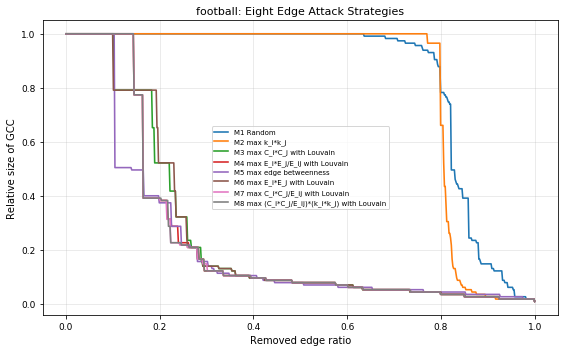

图已保存： C:\Users\86185\network collapse\result\football\football_seven_attacks.png
数据已保存： C:\Users\86185\network collapse\result\football\football_seven_attacks.csv
图片已保存： C:\Users\86185\network collapse\result\football\football_seven_attacks.png
开始处理网络：ca_netscience
路径： C:\Users\86185\network collapse\data\real_networks\ca-netscience
实际读取文件： C:\Users\86185\network collapse\data\real_networks\ca-netscience\ca-netscience.mtx
标准 Matrix Market 读取失败，改用边列表方式读取。
原始错误： ValueError('source is not in Matrix Market format')
节点数： 379
边数： 914
是否连通： True
------------------------------------------------------------
网络： ca_netscience
节点数： 379
边数： 914
初始 GCC 比例： 1.0
最大删除比例： 1.0
------------------------------------------------------------
正在运行：ca_netscience - M1 Random
完成：ca_netscience - M1 Random，用时 3.16 秒
------------------------------------------------------------
正在运行：ca_netscience - M2 max k_i*k_j
完成：ca_netscience - M2 max k_i*k_j，用时 4.02 秒
------------------------------------------------------------

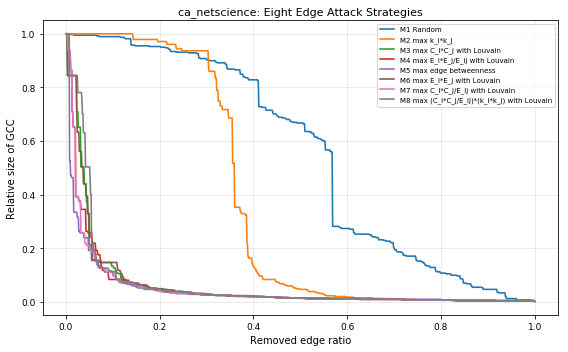

图已保存： C:\Users\86185\network collapse\result\ca_netscience\ca_netscience_seven_attacks.png
数据已保存： C:\Users\86185\network collapse\result\ca_netscience\ca_netscience_seven_attacks.csv
图片已保存： C:\Users\86185\network collapse\result\ca_netscience\ca_netscience_seven_attacks.png
开始处理网络：bio_diseasome
路径： C:\Users\86185\network collapse\data\real_networks\bio-diseasome
实际读取文件： C:\Users\86185\network collapse\data\real_networks\bio-diseasome\bio-diseasome.mtx
标准 Matrix Market 读取失败，改用边列表方式读取。
原始错误： ValueError('source is not in Matrix Market format')
节点数： 516
边数： 1188
是否连通： True
------------------------------------------------------------
网络： bio_diseasome
节点数： 516
边数： 1188
初始 GCC 比例： 1.0
最大删除比例： 1.0
------------------------------------------------------------
正在运行：bio_diseasome - M1 Random
完成：bio_diseasome - M1 Random，用时 4.46 秒
------------------------------------------------------------
正在运行：bio_diseasome - M2 max k_i*k_j
完成：bio_diseasome - M2 max k_i*k_j，用时 4.94 秒
----------------------------

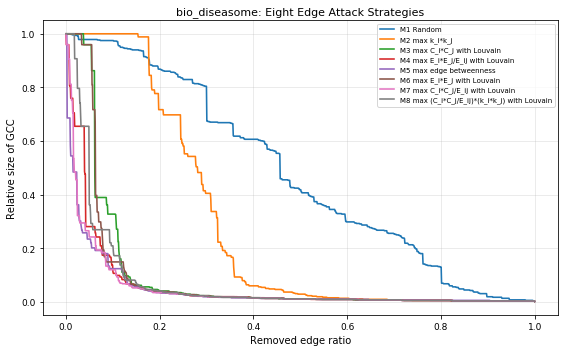

图已保存： C:\Users\86185\network collapse\result\bio_diseasome\bio_diseasome_seven_attacks.png
数据已保存： C:\Users\86185\network collapse\result\bio_diseasome\bio_diseasome_seven_attacks.csv
图片已保存： C:\Users\86185\network collapse\result\bio_diseasome\bio_diseasome_seven_attacks.png
开始处理网络：inf_USAir97
路径： C:\Users\86185\network collapse\data\real_networks\inf-USAir97
实际读取文件： C:\Users\86185\network collapse\data\real_networks\inf-USAir97\inf-USAir97.mtx
节点数： 332
边数： 2126
是否连通： True
------------------------------------------------------------
网络： inf_USAir97
节点数： 332
边数： 2126
初始 GCC 比例： 1.0
最大删除比例： 1.0
------------------------------------------------------------
正在运行：inf_USAir97 - M1 Random
完成：inf_USAir97 - M1 Random，用时 15.63 秒
------------------------------------------------------------
正在运行：inf_USAir97 - M2 max k_i*k_j
完成：inf_USAir97 - M2 max k_i*k_j，用时 19.37 秒
------------------------------------------------------------
正在运行：inf_USAir97 - M3 max C_i*C_j with Louvain
完成：inf_USAir97 - M3 max C_i

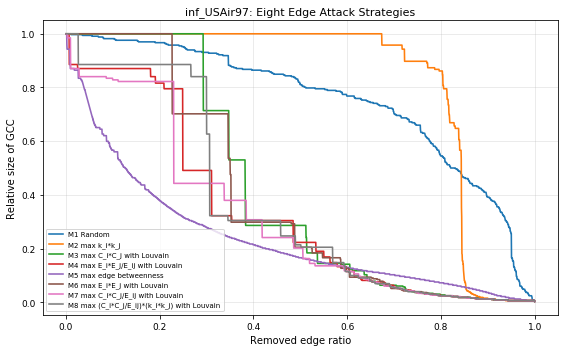

图已保存： C:\Users\86185\network collapse\result\inf_USAir97\inf_USAir97_seven_attacks.png
数据已保存： C:\Users\86185\network collapse\result\inf_USAir97\inf_USAir97_seven_attacks.csv
图片已保存： C:\Users\86185\network collapse\result\inf_USAir97\inf_USAir97_seven_attacks.png
全部完成！所有 real networks 的七种攻击结果在 result 文件夹里。


In [4]:
def run_one_dataset(name, path):
    """
    对一个网络执行七种攻击，并保存 CSV 和 PNG。
    """
    print("=" * 70)
    print(f"开始处理网络：{name}")
    print("路径：", path)

    G = load_simple_graph(path)

    print("网络：", name)
    print("节点数：", G.number_of_nodes())
    print("边数：", G.number_of_edges())
    print("初始 GCC 比例：", gcc_ratio(G, G.number_of_nodes()))
    print("最大删除比例：", MAX_REMOVE_FRAC)

    out_dir = RESULT_DIR / name
    out_dir.mkdir(exist_ok=True)

    all_records = []

    for method_label, method_key in METHODS:
        print("-" * 60)
        print(f"正在运行：{name} - {method_label}")
        t0 = time.time()

        records = simulate_attack(
            G0=G,
            method_key=method_key,
            method_label=method_label,
            seed=SEED,
            max_remove_frac=MAX_REMOVE_FRAC,
        )

        all_records.extend(records)

        elapsed = time.time() - t0
        print(f"完成：{name} - {method_label}，用时 {elapsed:.2f} 秒")

    csv_path = out_dir / f"{name}_seven_attacks.csv"
    fig_path = out_dir / f"{name}_seven_attacks.png"

    save_records_to_csv(all_records, csv_path)

    plot_attack_results(
        all_records,
        title=f"{name}: Eight Edge Attack Strategies",
        fig_path=fig_path
    )

    print("数据已保存：", csv_path)
    print("图片已保存：", fig_path)

    return all_records


# 默认跑全部真实网络：会依次生成每个网络的七种攻击 CSV 和 PNG。
RUN_DATASETS = list(DATASETS.keys())

# 如果只想先测试一个网络，就把 RUN_DATASETS 改成下面这种列表形式，能明显缩短运行时间。
# RUN_DATASETS = ["karate"]
# RUN_DATASETS = ["ca_netscience"]

all_results = {}

for name in RUN_DATASETS:
    path = DATASETS[name]
    all_results[name] = run_one_dataset(name, path)

print("=" * 70)
print("全部完成！所有 real networks 的七种攻击结果在 result 文件夹里。")